In [7]:
import os
import fitz
import pandas as pd

In [8]:
def extract_text_from_pdf(pdf_path):
    text = ""

    try:
        doc = fitz.open(pdf_path)

        for page in doc:
            text += page.get_text()

    except Exception as e:
        print(f"Error reading {pdf_path}: {e}")

    return text

In [9]:
data_path = "../data"

resume_data = []

for category in os.listdir(data_path):

    category_path = os.path.join(data_path, category)

    if os.path.isdir(category_path):

        for file in os.listdir(category_path):

            if file.endswith(".pdf"):

                pdf_path = os.path.join(category_path, file)

                resume_text = extract_text_from_pdf(pdf_path)

                resume_data.append({
                    "Category": category,
                    "Resume": resume_text
                })

In [10]:
df = pd.DataFrame(resume_data)
df.head()

,Category,Resume
0,ACCOUNTANT,ACCOUNTANT\nSummary\nFinancial Accountant spec...
1,ACCOUNTANT,STAFF ACCOUNTANT\nSummary\nHighly analytical a...
2,ACCOUNTANT,ACCOUNTANT\nProfessional Summary\nTo obtain a ...
3,ACCOUNTANT,SENIOR ACCOUNTANT\nExperience\nCompany Name Ju...
4,ACCOUNTANT,SENIOR ACCOUNTANT\nProfessional Summary\nSenio...


In [11]:
df.shape

(2484, 2)

In [12]:
df.columns

Index(['Category', 'Resume'], dtype='str')

In [13]:
df['Category'].unique()

<ArrowStringArray>
[            'ACCOUNTANT',               'ADVOCATE',            'AGRICULTURE',
                'APPAREL',                   'ARTS',             'AUTOMOBILE',
               'AVIATION',                'BANKING',                    'BPO',
   'BUSINESS-DEVELOPMENT',                   'CHEF',           'CONSTRUCTION',
             'CONSULTANT',               'DESIGNER',          'DIGITAL-MEDIA',
            'ENGINEERING',                'FINANCE',                'FITNESS',
             'HEALTHCARE',                     'HR', 'INFORMATION-TECHNOLOGY',
       'PUBLIC-RELATIONS',                  'SALES',                'TEACHER']
Length: 24, dtype: str

In [14]:
df['Category'].value_counts()

Category
BUSINESS-DEVELOPMENT      120
INFORMATION-TECHNOLOGY    120
ACCOUNTANT                118
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
FINANCE                   118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
CONSULTANT                115
HEALTHCARE                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [15]:
df.isnull().sum()

Category    0
Resume      0
dtype: int64

In [16]:
print(df['Resume'][0][:1000])

ACCOUNTANT
Summary
Financial Accountant specializing in financial planning, reporting and analysis within the Department of Defense.
Highlights
Account reconciliations
Results-oriented
Financial reporting
Critical thinking
Accounting operations professional
Analysis of financial systems
ERP (Enterprise Resource Planning) software.
Excellent facilitator
Accomplishments
Served on a tiger team which identified and resolved General Ledger postings in DEAMS totaling $360B in accounting adjustments. This allowed
for the first successful fiscal year-end close for 2012.
In collaboration with DFAS Europe, developed an automated tool that identified duplicate obligations. This tool allowed HQ USAFE to
deobligate over $5M in duplicate obligations.
Experience
Company Name July 2011 to November 2012 Accountant 
City , State
Enterprise Resource Planning Office (ERO)
In this position as an Accountant assigned to the Defense Enterprise Accounting and Management System (DEAMS) ERO I was
responsible for

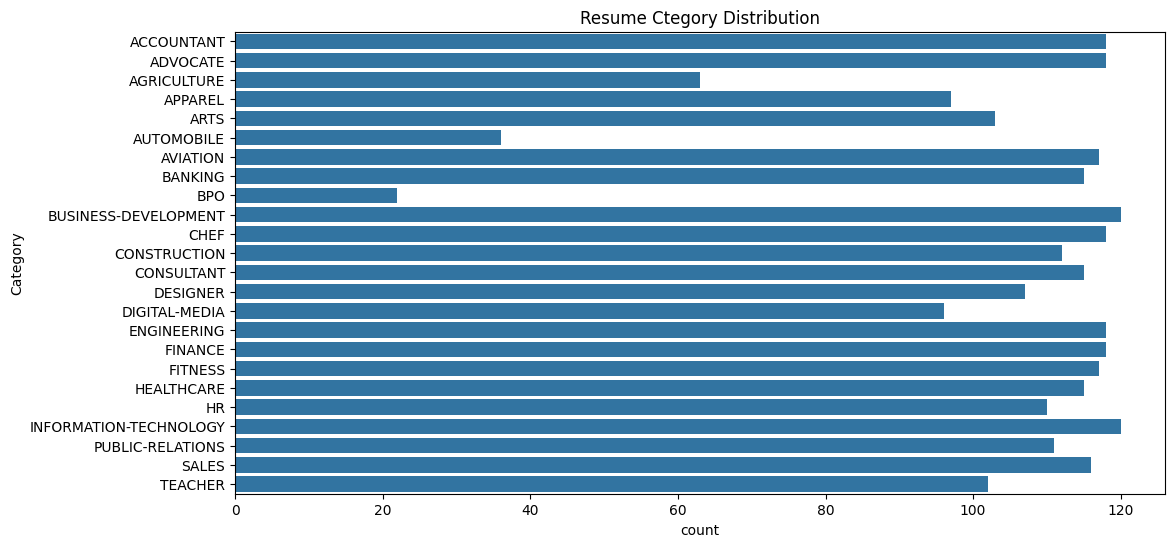

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.countplot(y = df['Category'])
plt.title('Resume Ctegory Distribution')
plt.show()

In [18]:
df.isnull().sum()

Category    0
Resume      0
dtype: int64

In [19]:
df['Resume_length'] = df['Resume'].apply(len)
df['Resume_length'].head()

0    24159
1     7493
2     4749
3     5922
4     5574
Name: Resume_length, dtype: int64

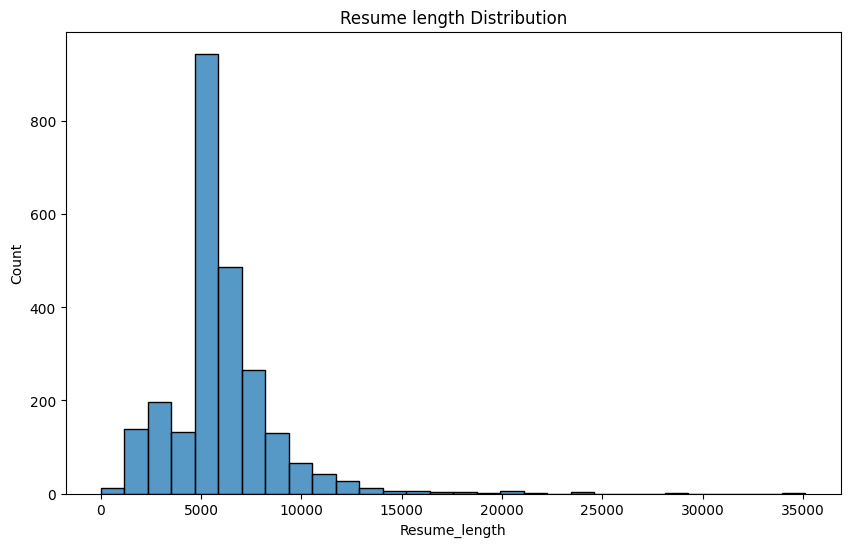

In [20]:
plt.figure(figsize=(10,6))
sns.histplot(df['Resume_length'], bins=30)
plt.title("Resume length Distribution")
plt.show()

In [21]:
print(df['Resume'][0][:1000])

ACCOUNTANT
Summary
Financial Accountant specializing in financial planning, reporting and analysis within the Department of Defense.
Highlights
Account reconciliations
Results-oriented
Financial reporting
Critical thinking
Accounting operations professional
Analysis of financial systems
ERP (Enterprise Resource Planning) software.
Excellent facilitator
Accomplishments
Served on a tiger team which identified and resolved General Ledger postings in DEAMS totaling $360B in accounting adjustments. This allowed
for the first successful fiscal year-end close for 2012.
In collaboration with DFAS Europe, developed an automated tool that identified duplicate obligations. This tool allowed HQ USAFE to
deobligate over $5M in duplicate obligations.
Experience
Company Name July 2011 to November 2012 Accountant 
City , State
Enterprise Resource Planning Office (ERO)
In this position as an Accountant assigned to the Defense Enterprise Accounting and Management System (DEAMS) ERO I was
responsible for

In [22]:
from collections import Counter

all_text = " ".join(df['Resume'])
words = all_text.split()
common_words = Counter(words).most_common(20)
common_words

[('and', 121898),
 ('to', 53232),
 ('of', 42496),
 ('the', 35443),
 ('for', 28040),
 ('in', 26940),
 ('with', 21410),
 (',', 18906),
 ('a', 15572),
 ('State', 15277),
 ('City', 14889),
 ('Company', 11810),
 ('Name', 11602),
 ('on', 9951),
 ('as', 9893),
 ('all', 8444),
 ('ï¼\u200b', 6890),
 ('by', 6649),
 ('customer', 5789),
 ('-', 5596)]

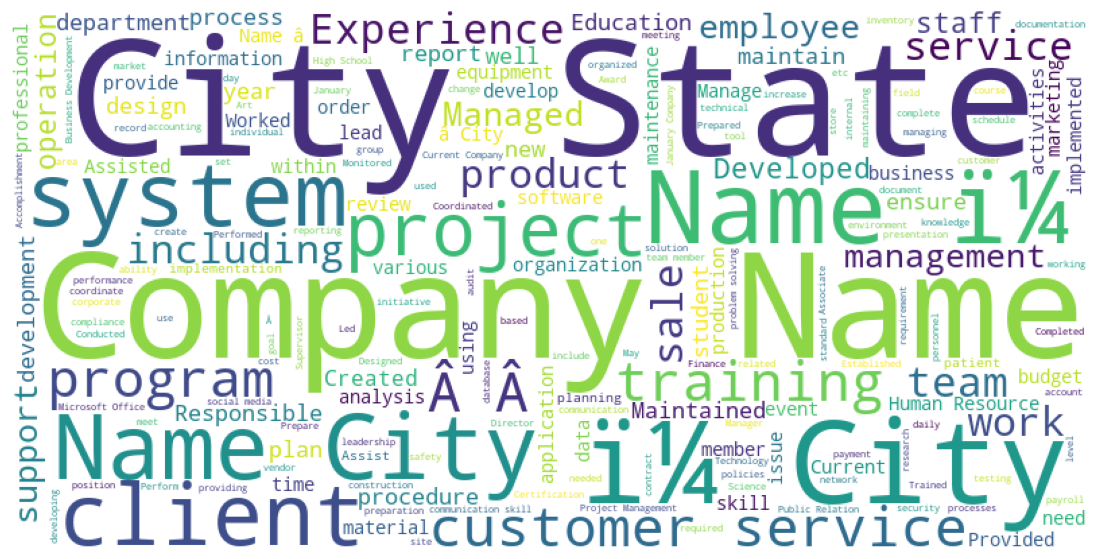

In [25]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height= 400, background_color = 'white').generate(all_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [28]:
import nltk

print("NLTK installed successfully")

NLTK installed successfully


In [29]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mvish\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [32]:
import re
import nltk

from nltk.corpus import stopwords

In [34]:
stop_words = set(stopwords.words('english'))
print(list(stop_words)[:20])

['how', 're', 'these', "don't", 'himself', 'am', "i'd", 'mightn', 'under', 'down', 'needn', 'he', 'weren', 'be', 'd', "he'll", 'then', 'couldn', "shan't", 'my']


In [35]:
def clean_resume(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d{10}', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    cleaned_text = " ".join(filtered_words)

    return cleaned_text

In [38]:
cleaned_resume = clean_resume(df['Resume'][0])

print(cleaned_resume[:2000])

accountant summary financial accountant specializing financial planning reporting analysis within department defense highlights account reconciliations resultsoriented financial reporting critical thinking accounting operations professional analysis financial systems erp enterprise resource planning software excellent facilitator accomplishments served tiger team identified resolved general ledger postings deams totaling b accounting adjustments allowed first successful fiscal yearend close collaboration dfas europe developed automated tool identified duplicate obligations tool allowed hq usafe deobligate duplicate obligations experience company name july november accountant city state enterprise resource planning office ero position accountant assigned defense enterprise accounting management system deams ero responsible identifying resolving issues affecting deams general ledger worked teammates procure pay orders cash budget report areas resolve daily challenges encountered deployme

In [39]:
df['Cleaned_Resume'] = df['Resume'].apply(clean_resume)
df.head()

,Category,Resume,Resume_length,Cleaned_Resume
0,ACCOUNTANT,ACCOUNTANT\nSummary\nFinancial Accountant spec...,24159,accountant summary financial accountant specia...
1,ACCOUNTANT,STAFF ACCOUNTANT\nSummary\nHighly analytical a...,7493,staff accountant summary highly analytical det...
2,ACCOUNTANT,ACCOUNTANT\nProfessional Summary\nTo obtain a ...,4749,accountant professional summary obtain positio...
3,ACCOUNTANT,SENIOR ACCOUNTANT\nExperience\nCompany Name Ju...,5922,senior accountant experience company name june...
4,ACCOUNTANT,SENIOR ACCOUNTANT\nProfessional Summary\nSenio...,5574,senior accountant professional summary senior ...


In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [41]:
tfidf = TfidfVectorizer(max_features=5000)

In [42]:
X = tfidf.fit_transform(df['Cleaned_Resume'])
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 678965 stored elements and shape (2484, 5000)>

In [44]:
y = df['Category']
y.head()

0    ACCOUNTANT
1    ACCOUNTANT
2    ACCOUNTANT
3    ACCOUNTANT
4    ACCOUNTANT
Name: Category, dtype: str

In [45]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_encoded

array([ 0,  0,  0, ..., 23, 23, 23], shape=(2484,))

In [46]:
dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))

{'ACCOUNTANT': 0,
 'ADVOCATE': 1,
 'AGRICULTURE': 2,
 'APPAREL': 3,
 'ARTS': 4,
 'AUTOMOBILE': 5,
 'AVIATION': 6,
 'BANKING': 7,
 'BPO': 8,
 'BUSINESS-DEVELOPMENT': 9,
 'CHEF': 10,
 'CONSTRUCTION': 11,
 'CONSULTANT': 12,
 'DESIGNER': 13,
 'DIGITAL-MEDIA': 14,
 'ENGINEERING': 15,
 'FINANCE': 16,
 'FITNESS': 17,
 'HEALTHCARE': 18,
 'HR': 19,
 'INFORMATION-TECHNOLOGY': 20,
 'PUBLIC-RELATIONS': 21,
 'SALES': 22,
 'TEACHER': 23}

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [49]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1987, 5000)
(1987,)
(497, 5000)
(497,)


In [50]:
from sklearn.naive_bayes import MultinomialNB

In [51]:
model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [52]:
y_pred = model.predict(X_test)
y_pred

array([23,  3,  0, 15, 20,  0, 22,  6, 22,  1, 20, 20, 21,  0, 15, 22, 21,
       23, 21,  0,  0,  0,  9, 23, 15, 20, 22,  6,  9,  6, 13, 19,  1,  6,
       20, 18,  0, 14, 23,  9,  7,  9, 17, 21,  0, 23,  9, 19,  1, 22, 23,
       19,  0, 23, 11, 19,  6,  0, 19, 20,  9, 14, 22, 15, 23, 16, 20, 10,
        1, 19, 21, 11, 20, 22, 23,  9,  2, 16,  9, 11,  0, 11, 14, 23, 20,
       14, 23,  4, 20,  1, 17,  9, 21,  0, 20, 20, 10, 23, 18, 15, 21,  0,
        9, 13,  7, 10, 13, 10,  1,  6,  6, 22, 23,  9, 22,  7,  9, 19, 13,
       19,  6, 16, 20,  1, 16, 19, 18,  1, 13, 10, 11,  7, 21, 19,  7,  9,
       19, 20, 20, 20,  0, 10, 19, 22, 15, 20, 20, 10,  0,  7, 21,  1, 15,
        6, 13, 22, 20, 20, 23,  9, 13, 15, 19, 21, 11,  0,  1, 15, 13, 20,
       18,  9, 23,  9, 11, 20, 23,  9, 20, 17, 22, 11,  0,  7, 22, 11,  1,
       21,  7, 17, 21, 22,  7, 14, 18,  9,  1, 15, 11, 19,  9, 22, 17, 10,
       19, 18,  1, 22, 18, 22,  0, 22,  7, 18,  0, 18,  9, 23, 19,  9, 21,
       11,  7, 22, 21, 20

In [53]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:" , accuracy)

Accuracy: 0.5331991951710262


In [54]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.42      0.95      0.58        19
           1       0.39      0.48      0.43        23
           2       1.00      0.12      0.22        16
           3       0.25      0.08      0.12        13
           4       1.00      0.06      0.11        33
           5       0.00      0.00      0.00         9
           6       0.62      0.58      0.60        26
           7       0.56      0.59      0.57        17
           8       0.00      0.00      0.00         5
           9       0.36      0.80      0.50        20
          10       0.63      0.71      0.67        17
          11       0.84      0.57      0.68        28
          12       1.00      0.05      0.10        20
          13       1.00      0.38      0.56        26
          14       0.90      0.47      0.62        19
          15       0.48      0.79      0.60        19
          16       0.70      0.29      0.41        24
          17       0.75    

c:\Users\mvish\OneDrive\Desktop\AI-Resume-Screening-System\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mvish\OneDrive\Desktop\AI-Resume-Screening-System\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mvish\OneDrive\Desktop\AI-Resume-Screening-System\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [55]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm 

array([[18,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         1,  0,  0,  0,  0,  0,  0,  0],
       [ 2, 11,  0,  0,  0,  0,  0,  3,  0,  1,  0,  0,  0,  0,  0,  0,
         0,  1,  1,  1,  0,  0,  2,  1],
       [ 1,  1,  2,  0,  0,  0,  0,  1,  0,  1,  0,  0,  0,  0,  0,  4,
         0,  0,  0,  0,  4,  1,  0,  1],
       [ 0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,
         1,  0,  0,  0,  0,  2,  8,  0],
       [ 0,  0,  0,  0,  2,  0,  3,  1,  0,  2,  1,  0,  0,  0,  0,  0,
         0,  2,  2,  0,  1,  2,  7, 10],
       [ 0,  3,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  3,  0,  2,  0],
       [ 1,  1,  0,  0,  0,  0, 15,  0,  0,  0,  2,  0,  0,  0,  0,  2,
         0,  0,  0,  1,  2,  0,  2,  0],
       [ 1,  0,  0,  0,  0,  0,  0, 10,  0,  2,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  4,  0,  0,  0],
       [ 0,  1,  0,  0,  0,  0,  0,  1,  0,  1,  0,  0,  0,  0,  0,  1,
         0,  0,  0,  1, 

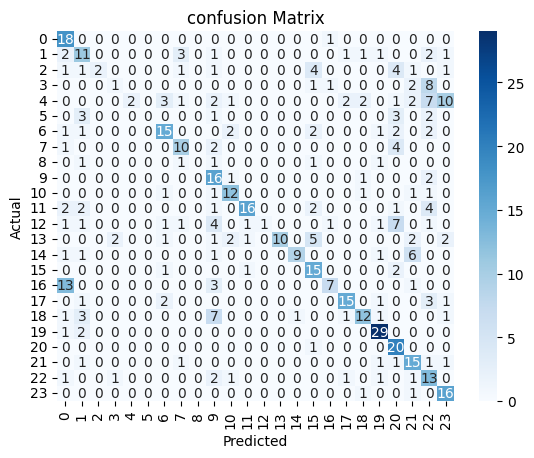

In [56]:
plt.Figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [58]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [59]:
lr_pred = lr_model.predict(X_test)

In [60]:
lr_accuracy = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:" , lr_accuracy)

Logistic Regression Accuracy: 0.6317907444668008


In [61]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.62      0.79      0.70        19
           1       0.38      0.57      0.46        23
           2       0.67      0.25      0.36        16
           3       0.43      0.23      0.30        13
           4       0.38      0.15      0.22        33
           5       0.00      0.00      0.00         9
           6       0.68      0.73      0.70        26
           7       0.45      0.59      0.51        17
           8       0.00      0.00      0.00         5
           9       0.62      0.75      0.68        20
          10       0.76      0.76      0.76        17
          11       0.86      0.68      0.76        28
          12       0.47      0.35      0.40        20
          13       1.00      0.85      0.92        26
          14       0.71      0.63      0.67        19
          15       0.62      0.84      0.71        19
          16       0.74      0.58      0.65        24
          17       0.80    

c:\Users\mvish\OneDrive\Desktop\AI-Resume-Screening-System\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mvish\OneDrive\Desktop\AI-Resume-Screening-System\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mvish\OneDrive\Desktop\AI-Resume-Screening-System\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [62]:
from sklearn.ensemble import RandomForestClassifier

In [64]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [65]:
rf_pred = rf_model.predict(X_test)

In [66]:
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Foresr Accuracy:" , rf_accuracy)

Random Foresr Accuracy: 0.6841046277665996


In [68]:
print("Naive Bayes Accuracy:" , accuracy)
print("Logistic Regression Accuracy:", lr_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Naive Bayes Accuracy: 0.5331991951710262
Logistic Regression Accuracy: 0.6317907444668008
Random Forest Accuracy: 0.6841046277665996


In [72]:
import joblib

In [73]:
joblib.dump(
    rf_model,
    '../models/resume_classifier.pkl'
)

['../models/resume_classifier.pkl']

In [74]:
joblib.dump(
    tfidf,
    '../models/tfidf_vectorizer.pkl'
)

['../models/tfidf_vectorizer.pkl']

In [75]:
joblib.dump(
    label_encoder,
    '../models/label_encoder.pkl'
)

['../models/label_encoder.pkl']